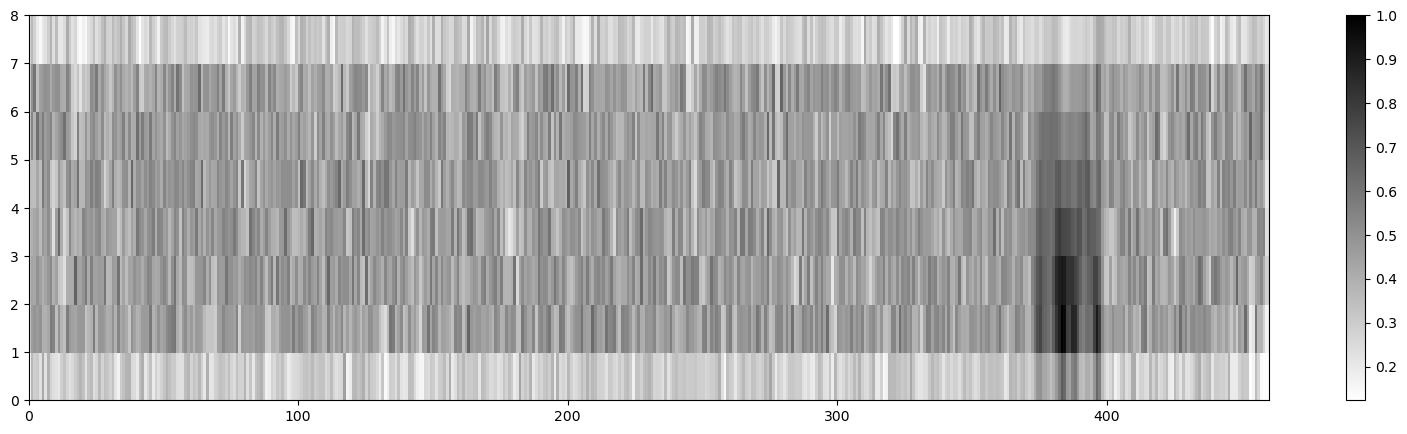

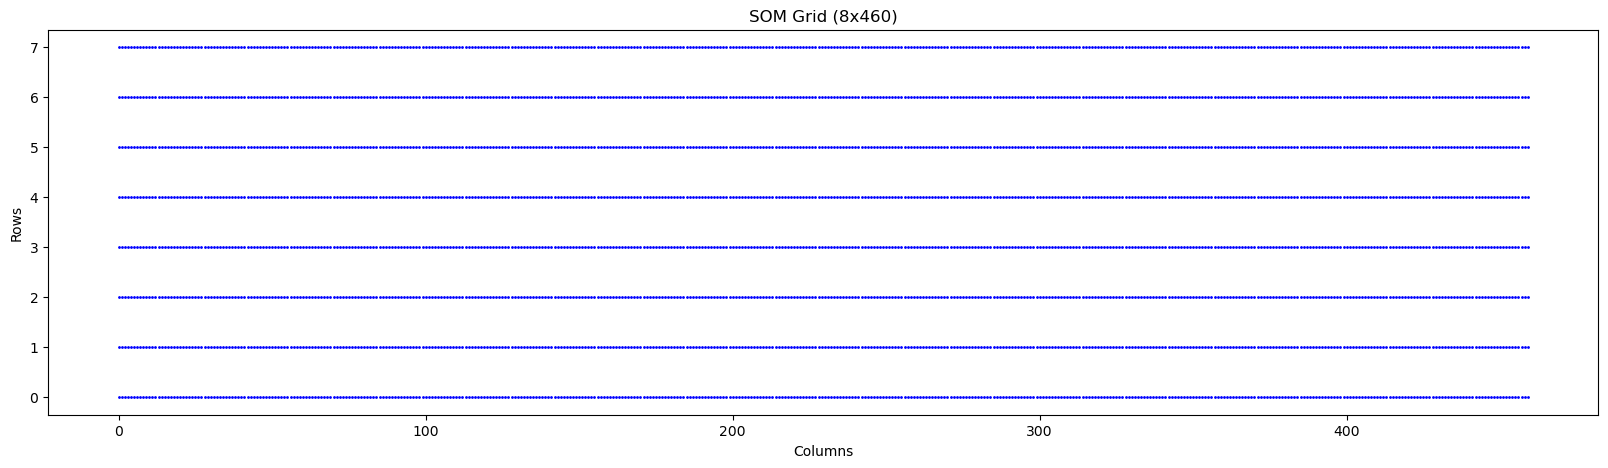

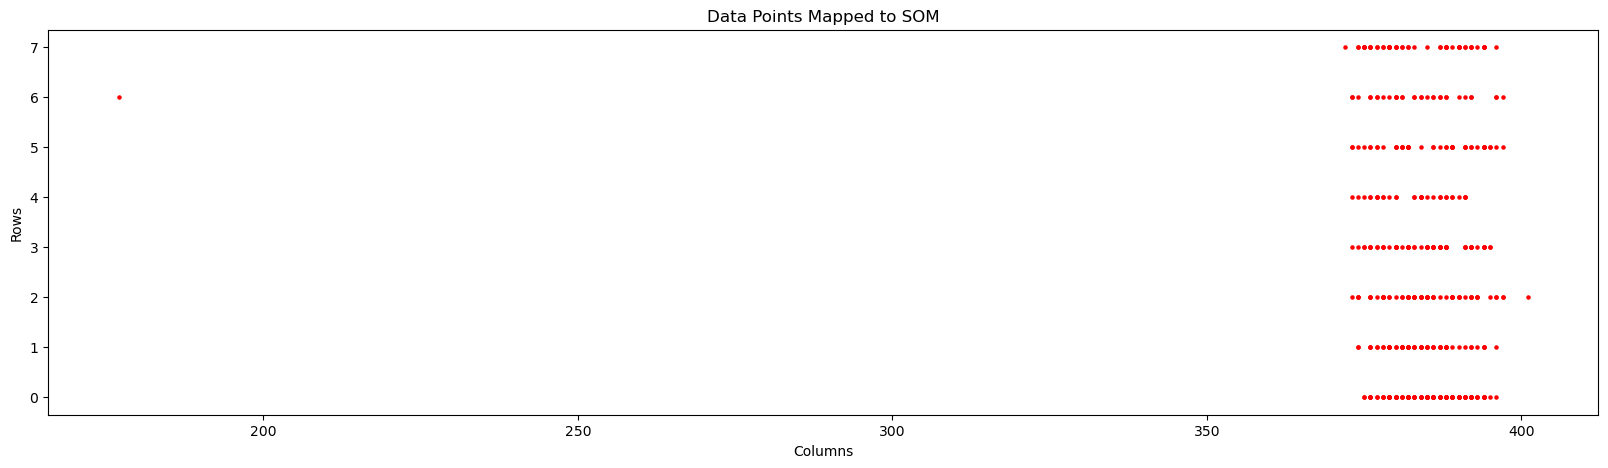

SOM training completed.
SOM size: 8 x 460
Data shape: (460, 2)


In [8]:
import numpy as np
from minisom import MiniSom
import matplotlib.pyplot as plt

# Generate synthetic data for 460 timestamps
# Assuming 2 features per timestamp (e.g., x and y coordinates)
n_samples = 460
n_features = 2
np.random.seed(42)  # For reproducibility
data = np.random.rand(n_samples, n_features) * 20  # Scale to 0-10

# Create SOM with 8 rows and 460 columns
som_rows = 8
som_cols = 460

ALPHA = 0.5
DECAY_FUNC = 'linear_decay_to_zero'
SIGMA0 = 1.5
SIGMA_DECAY_FUNC = 'linear_decay_to_one'
NEIGHBORHOOD_FUNC = 'gaussian'
DISTANCE_FUNC = 'euclidean'
TOPOLOGY = 'rectangular'
RANDOM_SEED = 123

som = MiniSom(
        som_rows,
        som_cols,
        n_features,
        sigma=SIGMA0,
        learning_rate=ALPHA,
        neighborhood_function=NEIGHBORHOOD_FUNC,
        activation_distance=DISTANCE_FUNC,
        topology=TOPOLOGY,
        sigma_decay_function = SIGMA_DECAY_FUNC,
        decay_function = DECAY_FUNC,
        random_seed=RANDOM_SEED,
        )

# Train the SOM
som.train_random(data, 1000)  # 1000 iterations

# Get the winner neurons for each data point
winners = np.array([som.winner(x) for x in data])

# Plot the SOM grid (simplified, since 460 columns is large)
# Plot the positions of the neurons

plt.figure(figsize=(20,5))
#plot the distance map
plt.pcolor(som.distance_map(), cmap='gist_yarg') 
# show the color bar
plt.colorbar()
plt.show()

plt.figure(figsize=(20, 5))
for i in range(som_rows):
    for j in range(som_cols):
        plt.scatter(j, i, c='blue', s=1)
plt.title('SOM Grid (8x460)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

# Plot the data points mapped to the SOM
plt.figure(figsize=(20, 5))
for i, winner in enumerate(winners):
    plt.scatter(winner[1], winner[0], c='red', s=5)
plt.title('Data Points Mapped to SOM')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

print("SOM training completed.")
print(f"SOM size: {som_rows} x {som_cols}")
print(f"Data shape: {data.shape}")
